# Augmented Scene Generation

This notebook creates synthetic UNO scenes from the extracted reference-card crops.
Each scene contains 0 to 6 cards for each player, one center card, and one active-player token.
It saves RGB scenes under `training_images/augmented_scenes` and card segmentation masks under `training_masks/augmented_scenes`.

Masks are generated from per-card visible instances, then each instance is slightly eroded before the final binary mask is written. This creates a small black gap between overlapping cards so a segmenter can learn clean card boundaries.

In [40]:
from __future__ import annotations

import csv
import json
import math
import re
import shutil
from dataclasses import dataclass
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
while not ((PROJECT_ROOT / "project" / "training_data").exists() and (PROJECT_ROOT / "data").exists()):
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not locate the workspace root containing project/training_data and data/.")
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_DIR = PROJECT_ROOT / "project"
TRAINING_DATA = PROJECT_DIR / "training_data"
REFERENCE_CSV = TRAINING_DATA / "object_labels" / "reference_cards" / "reference_do.csv"
REF_CARDS_DIR = TRAINING_DATA / "training_images" / "reference_cards"
FUNKY_BG_PATH = TRAINING_DATA / "funky_bg.jpg"

AUG_CARDS_DIR = TRAINING_DATA / "training_images" / "augmented_cards"
AUG_LABELS_DIR = TRAINING_DATA / "object_labels" / "augmented_cards"
AUG_CSV_PATH = AUG_LABELS_DIR / "aug.csv"

SCENES_IMG_DIR = TRAINING_DATA / "training_images" / "augmented_scenes"
SCENES_MASK_DIR = TRAINING_DATA / "training_masks" / "augmented_scenes"
SCENES_LABELS_DIR = TRAINING_DATA / "object_labels" / "augmented_scenes"
SCENES_LABELS_PATH = SCENES_LABELS_DIR / "labels.json"

TOKEN_ASSET_DIR = TRAINING_DATA / "training_images" / "token_crops"
TOKEN_STYLE_DIRS = {
    "white_rect": "white_rectangular_black",
    "funky_round": "funky_yellow_round",
}
PLAYERS = ("p1", "p2", "p3", "p4")

for output_dir in (AUG_CARDS_DIR, AUG_LABELS_DIR, SCENES_IMG_DIR, SCENES_MASK_DIR, SCENES_LABELS_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)

for style_dir in TOKEN_STYLE_DIRS.values():
    for player_name in PLAYERS:
        (TOKEN_ASSET_DIR / style_dir / player_name).mkdir(parents=True, exist_ok=True)

SEED = 42
N_AUG_PER_REFERENCE = 50
AUG_CARD_CANVAS = (256, 256)
AUG_CARD_HEIGHT_RANGE = (140, 220)
AUG_CARD_ANGLE_RANGE_DEG = (-25.0, 25.0)
AUG_CARD_SHIFT_FRACTION = 0.12

N_SCENES = 3000
SCENE_WIDTH = 1280
SCENE_HEIGHT = 720
MIN_CARDS_PER_PLAYER = 0
MAX_CARDS_PER_PLAYER = 4
# Wider erosion gap makes individual cards more separated in target masks.
MASK_GAP_PIXELS = 6
MIN_VISIBLE_CARD_AREA = 90
CLEAR_OUTPUT_DIRS = True

PLAYER_CARD_HEIGHT_FRACTION_RANGE = (0.2, 0.22)
CENTER_CARD_HEIGHT_FRACTION_RANGE = (0.2, 0.22)
# Wide spacing range allows either stronger overlap or clearly separated cards.
PLAYER_SLOT_SPACING_FACTOR_RANGE = (0.40, 1.5)
PLAYER_HAND_CENTER_JITTER_FRACTION_RANGE = (0.006, 0.03)
PLAYER_SLOT_OFFSET_JITTER_FRACTION_RANGE = (0.05, 0.20)
PLAYER_INWARD_JITTER_FRACTION_RANGE = (0.008, 0.03)
PLAYER_ROTATION_JITTER_DEG_RANGE = (4.0, 25.0)
CENTER_POSITION_FRACTION_RANGE_X = (0.40, 0.70)
CENTER_POSITION_FRACTION_RANGE_Y = (0.40, 0.70)
CENTER_ANGLE_RANGE_DEG = (-70.0, 70.0)

# Token placement hyperparameters (easy to tune).
TOKEN_INWARD_DISTANCE_FRACTION_RANGE = (0.0, 0.05)
TOKEN_LATERAL_DISTANCE_FRACTION_RANGE = (0.35, 0.50)
TOKEN_SIDE_MODE = "right"  # right | left | center | random
TOKEN_CENTER_JITTER_FRACTION = 0.008
TOKEN_CLAMP_MARGIN_FRACTION = 0.02

print(f"Project root: {PROJECT_ROOT}")
print(f"Reference cards: {REF_CARDS_DIR}")
print(f"Reference labels: {REFERENCE_CSV}")
print(f"Funky background: {FUNKY_BG_PATH}")
print(f"Augmented cards: {AUG_CARDS_DIR}")
print(f"Augmented labels: {AUG_CSV_PATH}")
print(f"Scene images: {SCENES_IMG_DIR}")
print(f"Scene masks: {SCENES_MASK_DIR}")
print(f"Token crop folders: {TOKEN_ASSET_DIR}")

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do
Reference cards: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\training_images\reference_cards
Reference labels: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\object_labels\reference_cards\reference_do.csv
Funky background: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\funky_bg.jpg
Augmented cards: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\training_images\augmented_cards
Augmented labels: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\object_labels\augmented_cards\aug.csv
Scene images: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\training_images\augmented_scenes
Scene masks: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\training_masks\augmented_scenes
Token crop folders: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\training_images\token_crops


In [41]:
@dataclass(frozen=True)
class CardAsset:
    """Reference-card crop and its aligned binary mask."""

    image_id: str
    label: str
    image_bgr: np.ndarray
    mask: np.ndarray


@dataclass(frozen=True)
class TokenAsset:
    """Token crop with a foreground mask."""

    image_bgr: np.ndarray
    mask: np.ndarray
    source_path: Path | None


def natural_sort_key(path: Path) -> list[object]:
    """Return a key that sorts crop_2 before crop_10."""
    return [int(part) if part.isdigit() else part.lower() for part in re.split(r"(\d+)", path.name)]


def read_reference_labels(reference_csv: Path = REFERENCE_CSV) -> dict[str, str]:
    """Load image_id -> card label mappings from reference.csv."""
    labels: dict[str, str] = {}
    with reference_csv.open("r", newline="", encoding="utf-8") as csv_file:
        for row in csv.DictReader(csv_file):
            image_id = row["image_id"].strip()
            card_label = row["card"].strip()
            if image_id:
                labels[image_id] = card_label
    return labels


def load_crop_aligned_mask(tag_dir: Path, crop_index: int, target_shape: tuple[int, int]) -> np.ndarray:
    """Load masks/mask_i.jpg, with a closed-component fallback for older outputs."""
    target_height, target_width = target_shape
    mask_path = tag_dir / "masks" / f"mask_{crop_index}.jpg"
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        closed_path = tag_dir / "closed_components" / f"closed_component_{crop_index}.jpg"
        closed_mask = cv2.imread(str(closed_path), cv2.IMREAD_GRAYSCALE)
        if closed_mask is not None and np.count_nonzero(closed_mask) > 0:
            bbox_x, bbox_y, bbox_width, bbox_height = cv2.boundingRect(closed_mask)
            mask = closed_mask[bbox_y:bbox_y + bbox_height, bbox_x:bbox_x + bbox_width]
        else:
            mask = np.full((target_height, target_width), 255, dtype=np.uint8)

    if mask.shape[:2] != (target_height, target_width):
        mask = cv2.resize(mask, (target_width, target_height), interpolation=cv2.INTER_NEAREST)

    return (mask > 127).astype(np.uint8) * 255


def load_reference_card_assets() -> list[CardAsset]:
    """Load every labeled reference crop and its aligned mask."""
    labels = read_reference_labels()
    assets: list[CardAsset] = []

    for tag_dir in sorted([path for path in REF_CARDS_DIR.iterdir() if path.is_dir()]):
        crops_dir = tag_dir / "crops"
        if not crops_dir.exists():
            continue

        for crop_path in sorted(crops_dir.glob("crop_*.jpg"), key=natural_sort_key):
            crop_index = int(crop_path.stem.split("_")[-1])
            image_id = f"{tag_dir.name}_crop_{crop_index}"
            label = labels.get(image_id)
            if label is None:
                continue

            image_bgr = cv2.imread(str(crop_path), cv2.IMREAD_COLOR)
            if image_bgr is None:
                continue

            mask = load_crop_aligned_mask(tag_dir, crop_index, image_bgr.shape[:2])
            assets.append(CardAsset(image_id=image_id, label=label, image_bgr=image_bgr, mask=mask))

    if not assets:
        raise RuntimeError("No reference card crops were loaded. Run the reference-card extraction notebook first.")

    labels_loaded = sorted({asset.label for asset in assets})
    print(f"Loaded {len(assets)} reference crops across {len(labels_loaded)} labels.")
    return assets


def make_white_background(scene_height: int, scene_width: int) -> np.ndarray:
    """Create the clean white table background variant."""
    return np.full((scene_height, scene_width, 3), 255, dtype=np.uint8)


def make_fallback_funky_background(scene_height: int, scene_width: int, rng: np.random.Generator) -> np.ndarray:
    """Create a colorful procedural fallback if funky_bg.jpg is missing."""
    row_indices, col_indices = np.indices((scene_height, scene_width))
    base = np.zeros((scene_height, scene_width, 3), dtype=np.float32)
    base[..., 0] = 80 + 70 * np.sin(col_indices / 55.0)
    base[..., 1] = 120 + 80 * np.sin((row_indices + col_indices) / 85.0)
    base[..., 2] = 120 + 70 * np.cos(row_indices / 45.0)
    noise = rng.normal(0, 12, size=base.shape)
    return np.clip(base + noise, 0, 255).astype(np.uint8)


def make_funky_background(scene_height: int, scene_width: int, rng: np.random.Generator) -> np.ndarray:
    """Crop and resize the project funky background to fill the scene."""
    source_bgr = cv2.imread(str(FUNKY_BG_PATH), cv2.IMREAD_COLOR)
    if source_bgr is None:
        return make_fallback_funky_background(scene_height, scene_width, rng)

    source_height, source_width = source_bgr.shape[:2]
    cover_scale = max(scene_width / source_width, scene_height / source_height) * float(rng.uniform(1.0, 1.18))
    resized_width = max(scene_width, int(round(source_width * cover_scale)))
    resized_height = max(scene_height, int(round(source_height * cover_scale)))
    resized = cv2.resize(source_bgr, (resized_width, resized_height), interpolation=cv2.INTER_LINEAR)

    if rng.random() < 0.5:
        resized = cv2.flip(resized, 1)

    crop_x = int(rng.integers(0, max(1, resized_width - scene_width + 1)))
    crop_y = int(rng.integers(0, max(1, resized_height - scene_height + 1)))
    background = resized[crop_y:crop_y + scene_height, crop_x:crop_x + scene_width].copy()

    alpha = float(rng.uniform(0.92, 1.08))
    beta = float(rng.uniform(-8, 8))
    return cv2.convertScaleAbs(background, alpha=alpha, beta=beta)


def token_asset_paths(style_key: str, player_name: str) -> list[Path]:
    """Return token crop candidates for one style and player slot."""
    token_dir = TOKEN_ASSET_DIR / TOKEN_STYLE_DIRS[style_key] / player_name
    candidates: list[Path] = []
    for extension in ("*.png", "*.jpg", "*.jpeg", "*.webp"):
        candidates.extend(sorted(token_dir.glob(extension), key=natural_sort_key))
    return candidates


def token_mask_from_image(raw_image: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Convert a token image into BGR pixels plus a foreground mask."""
    if raw_image.ndim == 2:
        image_bgr = cv2.cvtColor(raw_image, cv2.COLOR_GRAY2BGR)
        mask = (raw_image < 245).astype(np.uint8) * 255
        return image_bgr, mask

    if raw_image.shape[2] == 4:
        image_bgr = raw_image[:, :, :3]
        alpha = raw_image[:, :, 3]
        mask = (alpha > 10).astype(np.uint8) * 255
        return image_bgr, mask

    image_bgr = raw_image[:, :, :3]
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    mask = ((gray < 245) | (hsv[:, :, 1] > 30)).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return image_bgr, mask


def crop_to_mask_bounds(image_bgr: np.ndarray, mask: np.ndarray, padding: int = 3) -> tuple[np.ndarray, np.ndarray]:
    """Trim empty token borders before resizing."""
    nonzero = cv2.findNonZero(mask)
    if nonzero is None:
        return image_bgr, mask

    bbox_x, bbox_y, bbox_width, bbox_height = cv2.boundingRect(nonzero)
    top = max(0, bbox_y - padding)
    left = max(0, bbox_x - padding)
    bottom = min(mask.shape[0], bbox_y + bbox_height + padding)
    right = min(mask.shape[1], bbox_x + bbox_width + padding)
    return image_bgr[top:bottom, left:right], mask[top:bottom, left:right]


def resize_token_to_canvas(token: TokenAsset, target_size: tuple[int, int]) -> TokenAsset:
    """Resize a token crop into a fixed transparent canvas."""
    target_height, target_width = target_size
    cropped_image, cropped_mask = crop_to_mask_bounds(token.image_bgr, token.mask)
    source_height, source_width = cropped_image.shape[:2]
    scale = min(target_width / max(1, source_width), target_height / max(1, source_height))
    resized_width = max(1, int(round(source_width * scale)))
    resized_height = max(1, int(round(source_height * scale)))

    resized_image = cv2.resize(cropped_image, (resized_width, resized_height), interpolation=cv2.INTER_AREA)
    resized_mask = cv2.resize(cropped_mask, (resized_width, resized_height), interpolation=cv2.INTER_NEAREST)

    canvas_image = np.zeros((target_height, target_width, 3), dtype=np.uint8)
    canvas_mask = np.zeros((target_height, target_width), dtype=np.uint8)
    offset_x = (target_width - resized_width) // 2
    offset_y = (target_height - resized_height) // 2
    canvas_image[offset_y:offset_y + resized_height, offset_x:offset_x + resized_width] = resized_image
    canvas_mask[offset_y:offset_y + resized_height, offset_x:offset_x + resized_width] = resized_mask
    return TokenAsset(canvas_image, canvas_mask, token.source_path)


def make_placeholder_token(style_key: str, player_name: str, target_size: tuple[int, int]) -> TokenAsset:
    """Draw a synthetic token until real player-position token crops are available."""
    target_height, target_width = target_size
    image_bgr = np.zeros((target_height, target_width, 3), dtype=np.uint8)
    mask = np.zeros((target_height, target_width), dtype=np.uint8)
    margin = max(2, int(round(min(target_height, target_width) * 0.08)))

    if style_key == "white_rect":
        cv2.rectangle(
            image_bgr,
            (margin, margin),
            (target_width - margin - 1, target_height - margin - 1),
            (0, 0, 0),
            thickness=-1,
        )
        cv2.rectangle(
            mask,
            (margin, margin),
            (target_width - margin - 1, target_height - margin - 1),
            255,
            thickness=-1,
        )
    else:
        radius = max(2, (min(target_height, target_width) // 2) - margin)
        center = (target_width // 2, target_height // 2)
        cv2.circle(image_bgr, center, radius, (0, 220, 255), thickness=-1, lineType=cv2.LINE_AA)
        cv2.circle(mask, center, radius, 255, thickness=-1, lineType=cv2.LINE_AA)

    return TokenAsset(image_bgr, mask, None)


def token_target_size(style_key: str, player_name: str, scene_height: int) -> tuple[int, int]:
    """Choose a token canvas size that fits each player side."""
    base_size = max(28, int(round(scene_height * 0.055)))
    if style_key == "white_rect":
        if player_name in ("p2", "p4"):
            return base_size * 2, base_size
        return base_size, base_size * 2
    return base_size * 2, base_size * 2


def load_or_make_token(style_key: str, player_name: str, rng: np.random.Generator, scene_height: int) -> TokenAsset:
    """Load a real token crop if present, otherwise draw the configured placeholder."""
    target_size = token_target_size(style_key, player_name, scene_height)
    candidates = token_asset_paths(style_key, player_name)
    if candidates:
        selected_path = candidates[int(rng.integers(0, len(candidates)))]
        raw_image = cv2.imread(str(selected_path), cv2.IMREAD_UNCHANGED)
        if raw_image is not None:
            image_bgr, mask = token_mask_from_image(raw_image)
            return resize_token_to_canvas(TokenAsset(image_bgr, mask, selected_path), target_size)

    return make_placeholder_token(style_key, player_name, target_size)


def make_background(style_key: str, scene_height: int, scene_width: int, rng: np.random.Generator) -> np.ndarray:
    """Create the background that matches the requested token style."""
    if style_key == "white_rect":
        return make_white_background(scene_height, scene_width)
    return make_funky_background(scene_height, scene_width, rng)

In [42]:
PLAYER_LAYOUTS = {
    "p1": {"center": (0.50, 0.84), "axis": (1.0, 0.0), "inward": (0.0, -1.0), "angle": 0.0},
    "p2": {"center": (0.84, 0.50), "axis": (0.0, 1.0), "inward": (-1.0, 0.0), "angle": -90.0},
    "p3": {"center": (0.50, 0.16), "axis": (1.0, 0.0), "inward": (0.0, 1.0), "angle": 180.0},
    "p4": {"center": (0.16, 0.50), "axis": (0.0, 1.0), "inward": (1.0, 0.0), "angle": 90.0},
}

TOKEN_SLOTS = {
    "p1": (0.50, 0.67),
    "p2": (0.68, 0.50),
    "p3": (0.50, 0.33),
    "p4": (0.32, 0.50),
}


def transform_card(asset: CardAsset, target_height: float, angle_degrees: float, rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """Resize, lightly color-jitter, and rotate one card crop and mask."""
    source_height, source_width = asset.image_bgr.shape[:2]
    scale = float(target_height) / max(1, source_height)
    resized_width = max(1, int(round(source_width * scale)))
    resized_height = max(1, int(round(source_height * scale)))

    resized_image = cv2.resize(asset.image_bgr, (resized_width, resized_height), interpolation=cv2.INTER_AREA)
    resized_mask = cv2.resize(asset.mask, (resized_width, resized_height), interpolation=cv2.INTER_NEAREST)

    alpha = float(rng.uniform(0.92, 1.08))
    beta = float(rng.uniform(-8, 8))
    resized_image = cv2.convertScaleAbs(resized_image, alpha=alpha, beta=beta)

    center = (resized_width / 2.0, resized_height / 2.0)
    rotation_matrix = cv2.getRotationMatrix2D(center, float(angle_degrees), 1.0)
    abs_cos = abs(rotation_matrix[0, 0])
    abs_sin = abs(rotation_matrix[0, 1])
    rotated_width = int(round(resized_height * abs_sin + resized_width * abs_cos))
    rotated_height = int(round(resized_height * abs_cos + resized_width * abs_sin))

    rotation_matrix[0, 2] += rotated_width / 2.0 - center[0]
    rotation_matrix[1, 2] += rotated_height / 2.0 - center[1]

    rotated_image = cv2.warpAffine(
        resized_image,
        rotation_matrix,
        (rotated_width, rotated_height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(255, 255, 255),
    )
    rotated_mask = cv2.warpAffine(
        resized_mask,
        rotation_matrix,
        (rotated_width, rotated_height),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )

    return rotated_image, (rotated_mask > 127).astype(np.uint8) * 255


def paste_patch(
    scene_bgr: np.ndarray,
    instance_map: np.ndarray,
    patch_bgr: np.ndarray,
    patch_mask: np.ndarray,
    center_xy: tuple[float, float],
    instance_id: int | None = None,
    erase_instances: bool = False,
) -> tuple[int, int, int, int] | None:
    """Paste a masked patch and optionally write or erase instance ids."""
    scene_height, scene_width = scene_bgr.shape[:2]
    patch_height, patch_width = patch_bgr.shape[:2]
    center_x, center_y = center_xy

    patch_left = int(round(center_x - patch_width / 2.0))
    patch_top = int(round(center_y - patch_height / 2.0))
    patch_right = patch_left + patch_width
    patch_bottom = patch_top + patch_height

    dst_left = max(0, patch_left)
    dst_top = max(0, patch_top)
    dst_right = min(scene_width, patch_right)
    dst_bottom = min(scene_height, patch_bottom)
    if dst_right <= dst_left or dst_bottom <= dst_top:
        return None

    src_left = dst_left - patch_left
    src_top = dst_top - patch_top
    src_right = src_left + (dst_right - dst_left)
    src_bottom = src_top + (dst_bottom - dst_top)

    mask_patch = patch_mask[src_top:src_bottom, src_left:src_right] > 127
    if not np.any(mask_patch):
        return None

    image_patch = patch_bgr[src_top:src_bottom, src_left:src_right]
    scene_roi = scene_bgr[dst_top:dst_bottom, dst_left:dst_right]
    instance_roi = instance_map[dst_top:dst_bottom, dst_left:dst_right]

    scene_roi[mask_patch] = image_patch[mask_patch]
    if instance_id is not None:
        instance_roi[mask_patch] = instance_id
    if erase_instances:
        instance_roi[mask_patch] = 0

    visible_y, visible_x = np.where(mask_patch)
    bbox_left = int(dst_left + visible_x.min())
    bbox_top = int(dst_top + visible_y.min())
    bbox_right = int(dst_left + visible_x.max() + 1)
    bbox_bottom = int(dst_top + visible_y.max() + 1)
    return bbox_left, bbox_top, bbox_right, bbox_bottom


def separated_binary_mask(instance_map: np.ndarray, gap_pixels: int = MASK_GAP_PIXELS) -> np.ndarray:
    """Convert visible card instances to one binary mask with small gaps between instances."""
    binary_mask = np.zeros(instance_map.shape, dtype=np.uint8)
    instance_ids = [int(instance_id) for instance_id in np.unique(instance_map) if instance_id > 0]

    if gap_pixels > 0:
        kernel_size = 2 * int(gap_pixels) + 1
        gap_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    else:
        gap_kernel = None

    for instance_id in instance_ids:
        visible_instance = (instance_map == instance_id).astype(np.uint8) * 255
        if np.count_nonzero(visible_instance) < MIN_VISIBLE_CARD_AREA:
            continue
        if gap_kernel is not None:
            visible_instance = cv2.erode(visible_instance, gap_kernel, iterations=1)
        if np.count_nonzero(visible_instance) >= MIN_VISIBLE_CARD_AREA:
            binary_mask[visible_instance > 0] = 255

    return binary_mask


def sample_card_asset(card_assets: list[CardAsset], rng: np.random.Generator) -> CardAsset:
    """Choose one reference card crop."""
    return card_assets[int(rng.integers(0, len(card_assets)))]


def clamped_center(center_xy: np.ndarray, scene_width: int, scene_height: int) -> tuple[float, float]:
    """Keep placement centers comfortably inside the image canvas."""
    margin_x = scene_width * 0.07
    margin_y = scene_height * 0.07
    center_x = float(np.clip(center_xy[0], margin_x, scene_width - margin_x))
    center_y = float(np.clip(center_xy[1], margin_y, scene_height - margin_y))
    return center_x, center_y


def player_card_placements(
    player_name: str,
    card_count: int,
    card_assets: list[CardAsset],
    scene_width: int,
    scene_height: int,
    rng: np.random.Generator,
) -> list[dict[str, object]]:
    """Sample card placements in the expected table region for one player."""
    if card_count <= 0:
        return []

    layout = PLAYER_LAYOUTS[player_name]
    base_center = np.array([layout["center"][0] * scene_width, layout["center"][1] * scene_height], dtype=np.float32)
    axis = np.array(layout["axis"], dtype=np.float32)
    inward = np.array(layout["inward"], dtype=np.float32)
    base_angle = float(layout["angle"])

    hand_center_jitter_scale = float(rng.uniform(*PLAYER_HAND_CENTER_JITTER_FRACTION_RANGE))
    base_center += np.array(
        [
            float(rng.normal(0, scene_width * hand_center_jitter_scale)),
            float(rng.normal(0, scene_height * hand_center_jitter_scale)),
        ],
        dtype=np.float32,
    )

    target_height = float(rng.uniform(*PLAYER_CARD_HEIGHT_FRACTION_RANGE) * scene_height)
    approximate_card_width = target_height * 0.64
    slot_spacing = approximate_card_width * float(rng.uniform(*PLAYER_SLOT_SPACING_FACTOR_RANGE))
    offsets = (np.arange(card_count, dtype=np.float32) - (card_count - 1) / 2.0) * slot_spacing

    slot_offset_jitter_scale = float(rng.uniform(*PLAYER_SLOT_OFFSET_JITTER_FRACTION_RANGE))
    inward_jitter_scale = float(rng.uniform(*PLAYER_INWARD_JITTER_FRACTION_RANGE))
    rotation_jitter_std = float(rng.uniform(*PLAYER_ROTATION_JITTER_DEG_RANGE))

    placements: list[dict[str, object]] = []
    for slot_index, offset in enumerate(offsets):
        offset_jitter = float(rng.normal(0, slot_spacing * slot_offset_jitter_scale))
        inward_jitter = float(rng.normal(0, scene_height * inward_jitter_scale))
        center = base_center + axis * (float(offset) + offset_jitter) + inward * inward_jitter
        center_xy = clamped_center(center, scene_width, scene_height)
        angle_degrees = base_angle + float(rng.normal(0, rotation_jitter_std))
        card_height = target_height * float(rng.uniform(0.90, 1.10))

        placements.append(
            {
                "owner": player_name,
                "slot_index": slot_index,
                "asset": sample_card_asset(card_assets, rng),
                "center": center_xy,
                "target_height": card_height,
                "angle_degrees": angle_degrees,
            }
        )

    return placements


def center_card_placement(
    card_assets: list[CardAsset],
    scene_width: int,
    scene_height: int,
    rng: np.random.Generator,
) -> dict[str, object]:
    """Sample the required center-card placement."""
    center = np.array(
        [
            scene_width * float(rng.uniform(*CENTER_POSITION_FRACTION_RANGE_X)),
            scene_height * float(rng.uniform(*CENTER_POSITION_FRACTION_RANGE_Y)),
        ],
        dtype=np.float32,
    )
    return {
        "owner": "center",
        "slot_index": 0,
        "asset": sample_card_asset(card_assets, rng),
        "center": clamped_center(center, scene_width, scene_height),
        "target_height": float(rng.uniform(*CENTER_CARD_HEIGHT_FRACTION_RANGE) * scene_height),
        "angle_degrees": float(rng.uniform(*CENTER_ANGLE_RANGE_DEG)),
    }


def token_side_sign(side_mode: str, rng: np.random.Generator) -> float:
    """Map token side mode to the lateral sign around the active player."""
    normalized_mode = side_mode.strip().lower()
    if normalized_mode == "right":
        return 1.0
    if normalized_mode == "left":
        return -1.0
    if normalized_mode == "center":
        return 0.0
    if normalized_mode == "random":
        return float(rng.choice([-1.0, 1.0]))
    raise ValueError(f"Invalid TOKEN_SIDE_MODE={side_mode!r}. Expected right, left, center, or random.")


def token_center(active_player: str, scene_width: int, scene_height: int, rng: np.random.Generator) -> tuple[float, float]:
    """Sample a token center near the active player using player-relative side placement."""
    layout = PLAYER_LAYOUTS[active_player]
    base_center = np.array([layout["center"][0] * scene_width, layout["center"][1] * scene_height], dtype=np.float32)
    inward = np.array(layout["inward"], dtype=np.float32)

    # Player-right is a +90 deg rotation in image coordinates.
    right = np.array([-inward[1], inward[0]], dtype=np.float32)

    inward_distance = scene_height * float(rng.uniform(*TOKEN_INWARD_DISTANCE_FRACTION_RANGE))
    lateral_distance = scene_height * float(rng.uniform(*TOKEN_LATERAL_DISTANCE_FRACTION_RANGE))
    side_sign = token_side_sign(TOKEN_SIDE_MODE, rng)

    jitter_scale = float(TOKEN_CENTER_JITTER_FRACTION)
    jitter_x = float(rng.normal(0, scene_width * jitter_scale))
    jitter_y = float(rng.normal(0, scene_height * jitter_scale))

    center = base_center + inward * inward_distance + right * (side_sign * lateral_distance)
    center += np.array([jitter_x, jitter_y], dtype=np.float32)

    margin_x = scene_width * float(TOKEN_CLAMP_MARGIN_FRACTION)
    margin_y = scene_height * float(TOKEN_CLAMP_MARGIN_FRACTION)
    center_x = float(np.clip(center[0], margin_x, scene_width - margin_x))
    center_y = float(np.clip(center[1], margin_y, scene_height - margin_y))
    return center_x, center_y


def compose_augmented_scene(
    card_assets: list[CardAsset],
    rng: np.random.Generator,
    scene_width: int = SCENE_WIDTH,
    scene_height: int = SCENE_HEIGHT,
) -> tuple[np.ndarray, np.ndarray, dict[str, object]]:
    """Compose one augmented scene, its separated card mask, and metadata."""
    style_key = "white_rect" if rng.random() < 0.5 else "funky_round"
    scene_bgr = make_background(style_key, scene_height, scene_width, rng)
    instance_map = np.zeros((scene_height, scene_width), dtype=np.uint16)

    player_counts = {
        player_name: int(rng.integers(MIN_CARDS_PER_PLAYER, MAX_CARDS_PER_PLAYER + 1))
        for player_name in PLAYERS
    }

    placements: list[dict[str, object]] = []
    for player_name in PLAYERS:
        placements.extend(
            player_card_placements(player_name, player_counts[player_name], card_assets, scene_width, scene_height, rng)
        )
    placements.append(center_card_placement(card_assets, scene_width, scene_height, rng))

    card_metadata: list[dict[str, object]] = []
    next_instance_id = 1
    for placement in placements:
        asset = placement["asset"]
        assert isinstance(asset, CardAsset)
        patch_bgr, patch_mask = transform_card(
            asset,
            target_height=float(placement["target_height"]),
            angle_degrees=float(placement["angle_degrees"]),
            rng=rng,
        )
        bbox = paste_patch(
            scene_bgr,
            instance_map,
            patch_bgr,
            patch_mask,
            center_xy=placement["center"],
            instance_id=next_instance_id,
        )
        if bbox is None:
            continue

        card_metadata.append(
            {
                "instance_id": next_instance_id,
                "owner": placement["owner"],
                "slot_index": int(placement["slot_index"]),
                "image_id": asset.image_id,
                "label": asset.label,
                "bbox": list(map(int, bbox)),
                "angle_degrees": float(placement["angle_degrees"]),
            }
        )
        next_instance_id += 1

    active_player = PLAYERS[int(rng.integers(0, len(PLAYERS)))]
    token = load_or_make_token(style_key, active_player, rng, scene_height)
    token_bbox = paste_patch(
        scene_bgr,
        instance_map,
        token.image_bgr,
        token.mask,
        center_xy=token_center(active_player, scene_width, scene_height, rng),
        erase_instances=True,
    )

    separated_mask = separated_binary_mask(instance_map, MASK_GAP_PIXELS)
    metadata = {
        "style": style_key,
        "active_player": active_player,
        "player_card_counts": player_counts,
        "center_card_count": 1,
        "token_bbox": list(map(int, token_bbox)) if token_bbox is not None else None,
        "token_source": str(token.source_path) if token.source_path is not None else "placeholder",
        "mask_gap_pixels": MASK_GAP_PIXELS,
        "cards": card_metadata,
    }
    return scene_bgr, separated_mask, metadata


print("Scene composer ready.")

Scene composer ready.


Loaded 54 reference crops across 54 labels.


100%|██████████| 2700/2700 [01:45<00:00, 25.58it/s]


Saved 2700 augmented cards to: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\training_images\augmented_cards
Saved augmented labels to: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\object_labels\augmented_cards\aug.csv


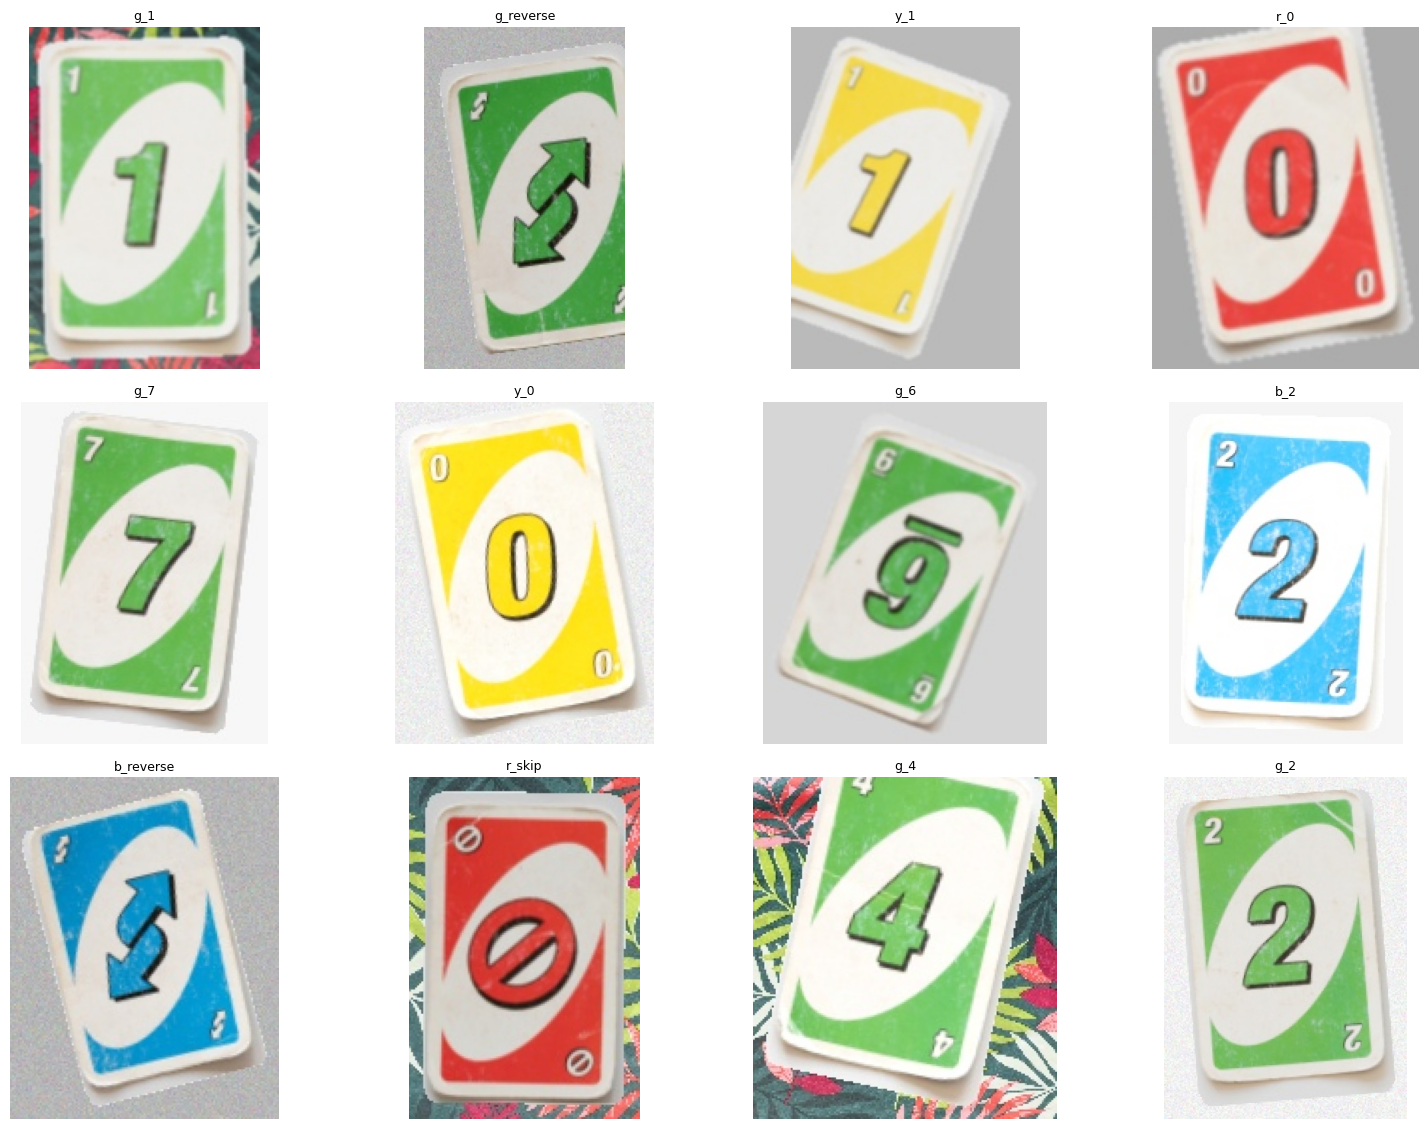

In [43]:
# Generate single-card augmented crops for classifier training.
try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda values: values


def clear_augmented_card_outputs() -> None:
    """Remove only files produced by this augmented-card generator."""
    AUG_CARDS_DIR.mkdir(parents=True, exist_ok=True)
    for output_file in AUG_CARDS_DIR.glob("aug_*.jpg"):
        if output_file.is_file():
            output_file.unlink()

    AUG_LABELS_DIR.mkdir(parents=True, exist_ok=True)
    if AUG_CSV_PATH.exists():
        AUG_CSV_PATH.unlink()


def render_augmented_card(asset: CardAsset, rng: np.random.Generator) -> np.ndarray:
    """Render one card crop on a simple synthetic background."""
    canvas_h, canvas_w = AUG_CARD_CANVAS
    target_height = float(rng.uniform(*AUG_CARD_HEIGHT_RANGE))
    angle_degrees = float(rng.uniform(*AUG_CARD_ANGLE_RANGE_DEG))
    patch_bgr, patch_mask = transform_card(
        asset,
        target_height=target_height,
        angle_degrees=angle_degrees,
        rng=rng,
    )

    if rng.random() < 0.6:
        tone = int(rng.integers(170, 256))
        canvas = np.full((canvas_h, canvas_w, 3), tone, dtype=np.uint8)
        if rng.random() < 0.5:
            noise = rng.normal(0, 8, size=canvas.shape)
            canvas = np.clip(canvas.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    else:
        canvas = make_funky_background(canvas_h, canvas_w, rng)

    instance_map = np.zeros((canvas_h, canvas_w), dtype=np.uint8)
    shift_x = float(rng.normal(0, canvas_w * AUG_CARD_SHIFT_FRACTION))
    shift_y = float(rng.normal(0, canvas_h * AUG_CARD_SHIFT_FRACTION))
    center_xy = (canvas_w / 2.0 + shift_x, canvas_h / 2.0 + shift_y)

    paste_patch(
        scene_bgr=canvas,
        instance_map=instance_map,
        patch_bgr=patch_bgr,
        patch_mask=patch_mask,
        center_xy=center_xy,
        instance_id=1,
    )

    foreground = instance_map > 0
    if np.any(foreground):
        ys, xs = np.where(foreground)
        padding = int(rng.integers(3, 10))
        x0 = max(0, int(xs.min()) - padding)
        y0 = max(0, int(ys.min()) - padding)
        x1 = min(canvas_w, int(xs.max()) + 1 + padding)
        y1 = min(canvas_h, int(ys.max()) + 1 + padding)
        canvas = canvas[y0:y1, x0:x1]

    if rng.random() < 0.2:
        canvas = cv2.GaussianBlur(canvas, (3, 3), sigmaX=0.0)

    return canvas


if CLEAR_OUTPUT_DIRS:
    clear_augmented_card_outputs()

rng_cards = np.random.default_rng(SEED + 1)
card_assets = load_reference_card_assets()
total_augmented = len(card_assets) * N_AUG_PER_REFERENCE
aug_rows: list[dict[str, str]] = []

for aug_index in tqdm(range(total_augmented)):
    asset = card_assets[aug_index % len(card_assets)]
    aug_img = render_augmented_card(asset, rng_cards)
    image_id = f"aug_{aug_index:05d}"
    image_path = AUG_CARDS_DIR / f"{image_id}.jpg"
    cv2.imwrite(str(image_path), aug_img, [int(cv2.IMWRITE_JPEG_QUALITY), 96])
    aug_rows.append({"image_id": image_id, "card": asset.label})

with AUG_CSV_PATH.open("w", newline="", encoding="utf-8") as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=["image_id", "card"])
    writer.writeheader()
    writer.writerows(aug_rows)

print(f"Saved {len(aug_rows)} augmented cards to: {AUG_CARDS_DIR}")
print(f"Saved augmented labels to: {AUG_CSV_PATH}")

preview_count = min(12, len(aug_rows))
if preview_count == 0:
    print("No augmented cards were generated.")
else:
    preview_indices = rng_cards.choice(len(aug_rows), size=preview_count, replace=False)
    cols = 4
    rows = int(np.ceil(preview_count / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.8 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, index in zip(axes, preview_indices):
        row = aug_rows[int(index)]
        image_path = AUG_CARDS_DIR / f"{row['image_id']}.jpg"
        image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        ax.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(row["card"], fontsize=9)
        ax.axis("off")

    for ax in axes[preview_count:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Loaded 54 reference crops across 54 labels.


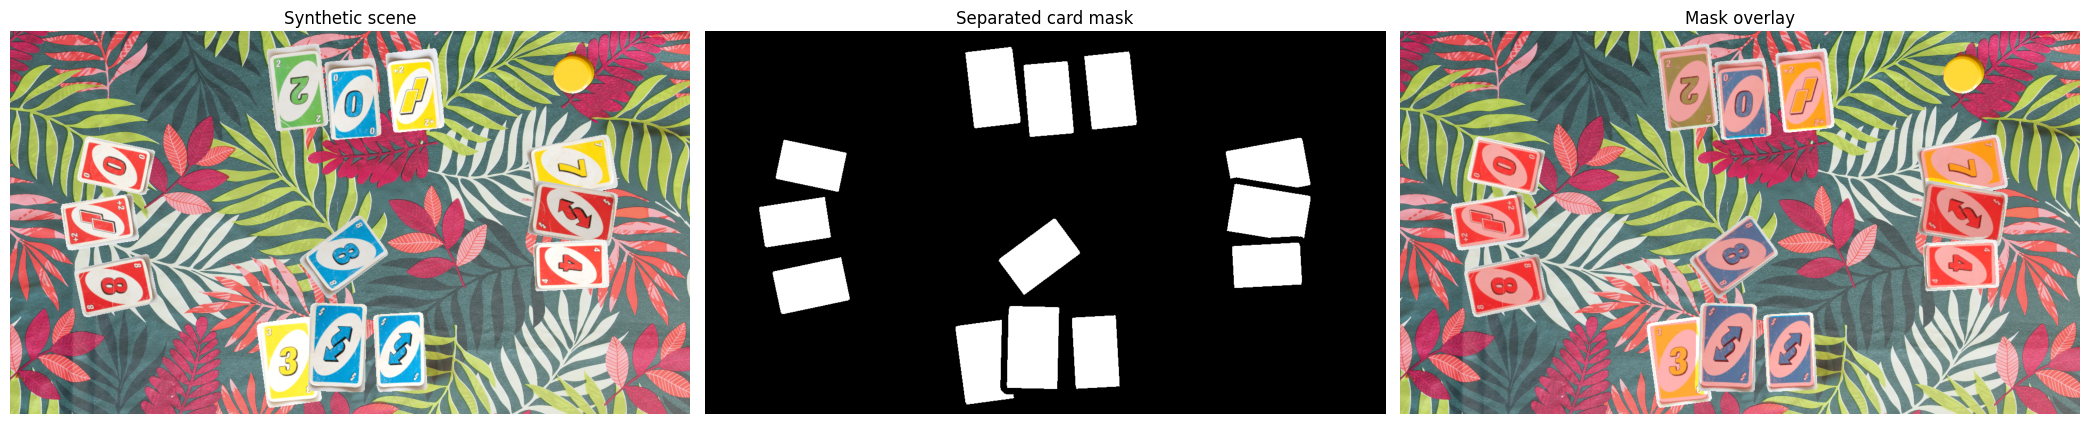

{
  "style": "funky_round",
  "active_player": "p2",
  "player_card_counts": {
    "p1": 3,
    "p2": 3,
    "p3": 3,
    "p4": 3
  },
  "visible_cards": 13,
  "token_source": "C:\\Users\\doria\\Documents\\EPFL\\IA\\iapr2026do\\project\\training_data\\training_images\\token_crops\\funky_yellow_round\\p2\\left_round.png"
}


In [44]:
# Preview one generated scene before producing the full dataset.
preview_rng = np.random.default_rng(SEED)
card_assets = load_reference_card_assets()
preview_scene_bgr, preview_mask, preview_metadata = compose_augmented_scene(card_assets, preview_rng)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
axes[0].imshow(cv2.cvtColor(preview_scene_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Synthetic scene")
axes[0].axis("off")

axes[1].imshow(preview_mask, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Separated card mask")
axes[1].axis("off")

overlay = cv2.cvtColor(preview_scene_bgr, cv2.COLOR_BGR2RGB).copy()
overlay[preview_mask > 0] = (0.65 * overlay[preview_mask > 0] + 0.35 * np.array([255, 40, 40])).astype(np.uint8)
axes[2].imshow(overlay)
axes[2].set_title("Mask overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(json.dumps({
    "style": preview_metadata["style"],
    "active_player": preview_metadata["active_player"],
    "player_card_counts": preview_metadata["player_card_counts"],
    "visible_cards": len(preview_metadata["cards"]),
    "token_source": preview_metadata["token_source"],
}, indent=2))

In [45]:
# Generate and save the augmented scene dataset.
try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda values: values


def clear_previous_outputs() -> None:
    """Remove only files produced by this scene generator."""
    for output_dir in (SCENES_IMG_DIR, SCENES_MASK_DIR):
        output_dir.mkdir(parents=True, exist_ok=True)
        for output_file in output_dir.glob("aug_scene_*"):
            if output_file.is_file():
                output_file.unlink()

    SCENES_LABELS_DIR.mkdir(parents=True, exist_ok=True)
    if SCENES_LABELS_PATH.exists():
        SCENES_LABELS_PATH.unlink()


if CLEAR_OUTPUT_DIRS:
    clear_previous_outputs()

rng_dataset = np.random.default_rng(SEED)
card_assets = load_reference_card_assets()
all_scene_metadata: list[dict[str, object]] = []

for scene_index in tqdm(range(N_SCENES)):
    scene_bgr, scene_mask, scene_metadata = compose_augmented_scene(card_assets, rng_dataset)
    scene_name = f"aug_scene_{scene_index:05d}"
    image_path = SCENES_IMG_DIR / f"{scene_name}.jpg"
    mask_path = SCENES_MASK_DIR / f"{scene_name}.png"

    cv2.imwrite(str(image_path), scene_bgr)
    cv2.imwrite(str(mask_path), scene_mask)

    scene_metadata = {
        "scene": scene_name,
        "image_path": str(image_path.relative_to(PROJECT_ROOT)),
        "mask_path": str(mask_path.relative_to(PROJECT_ROOT)),
        **scene_metadata,
    }
    all_scene_metadata.append(scene_metadata)

with SCENES_LABELS_PATH.open("w", encoding="utf-8") as labels_file:
    json.dump(all_scene_metadata, labels_file, indent=2)

print(f"Saved {len(all_scene_metadata)} scenes to: {SCENES_IMG_DIR}")
print(f"Saved {len(all_scene_metadata)} masks to:  {SCENES_MASK_DIR}")
print(f"Saved scene metadata to:   {SCENES_LABELS_PATH}")

Loaded 54 reference crops across 54 labels.


100%|██████████| 3000/3000 [03:59<00:00, 12.54it/s]


Saved 3000 scenes to: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\training_images\augmented_scenes
Saved 3000 masks to:  C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\training_masks\augmented_scenes
Saved scene metadata to:   C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\object_labels\augmented_scenes\labels.json


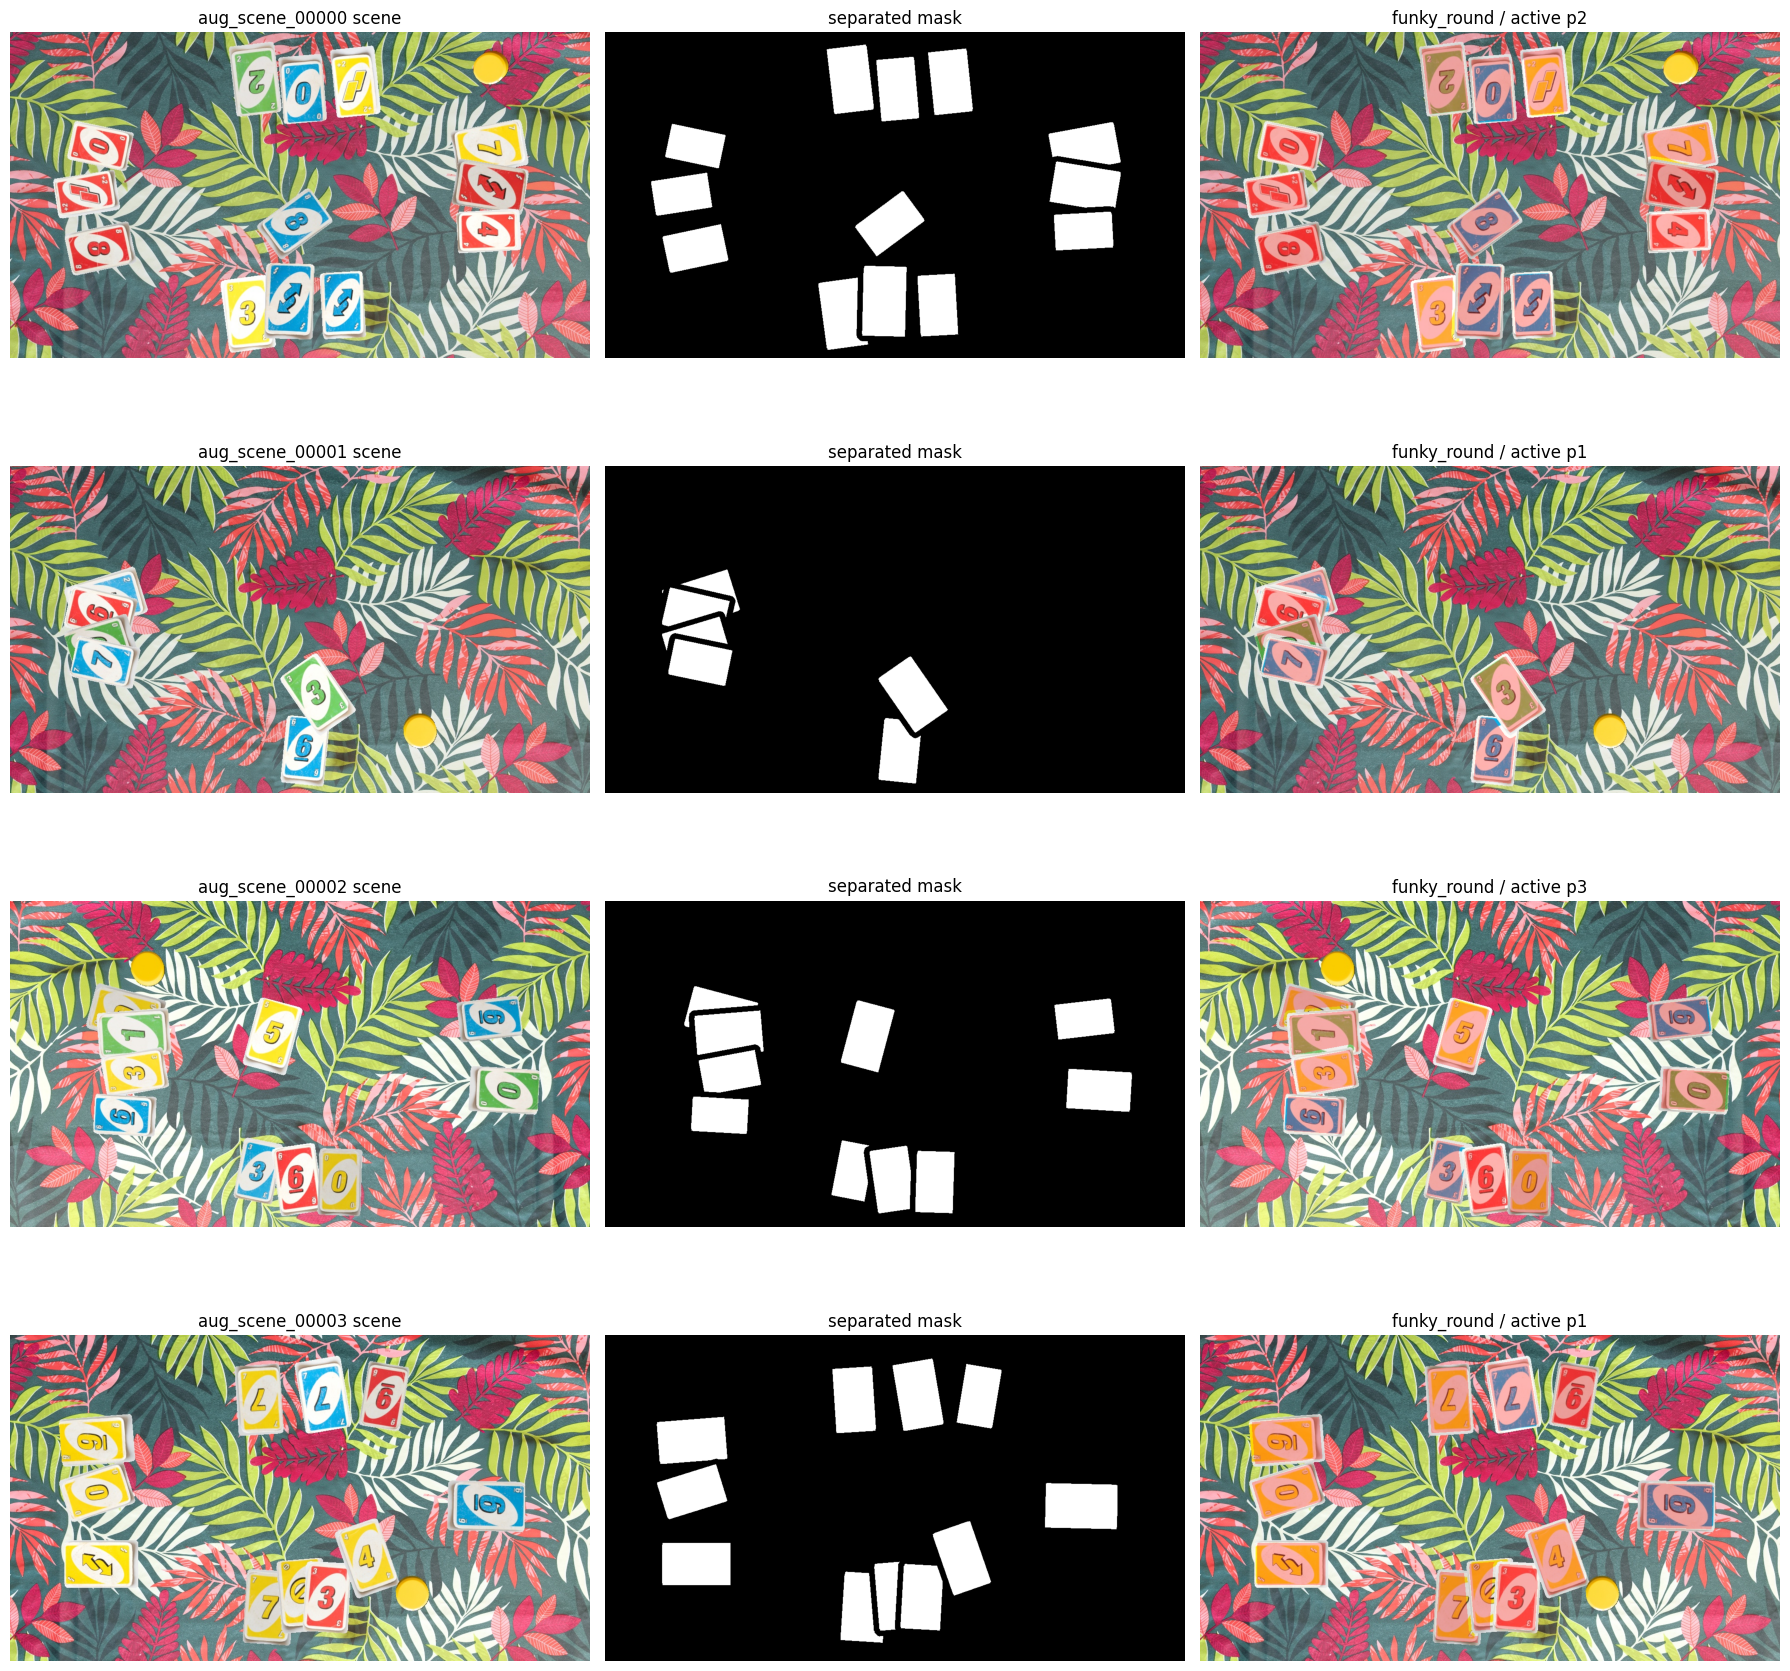

Previewed 4 saved samples from C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\object_labels\augmented_scenes\labels.json


In [46]:
# Quick visual check of saved outputs after generation.
if not SCENES_LABELS_PATH.exists():
    print("Run the generation cell first to create saved scenes and masks.")
else:
    with SCENES_LABELS_PATH.open("r", encoding="utf-8") as labels_file:
        saved_metadata = json.load(labels_file)

    sample_count = min(4, len(saved_metadata))
    fig, axes = plt.subplots(sample_count, 3, figsize=(18, 4.5 * sample_count))
    axes = np.atleast_2d(axes)

    for row_index, metadata in enumerate(saved_metadata[:sample_count]):
        image_path = PROJECT_ROOT / metadata["image_path"]
        mask_path = PROJECT_ROOT / metadata["mask_path"]
        scene_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        scene_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        overlay_rgb = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2RGB).copy()
        overlay_rgb[scene_mask > 0] = (0.65 * overlay_rgb[scene_mask > 0] + 0.35 * np.array([255, 40, 40])).astype(np.uint8)

        axes[row_index, 0].imshow(cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2RGB))
        axes[row_index, 0].set_title(f"{metadata['scene']} scene")
        axes[row_index, 0].axis("off")

        axes[row_index, 1].imshow(scene_mask, cmap="gray", vmin=0, vmax=255)
        axes[row_index, 1].set_title("separated mask")
        axes[row_index, 1].axis("off")

        axes[row_index, 2].imshow(overlay_rgb)
        axes[row_index, 2].set_title(f"{metadata['style']} / active {metadata['active_player']}")
        axes[row_index, 2].axis("off")

    plt.tight_layout()
    plt.show()
    print(f"Previewed {sample_count} saved samples from {SCENES_LABELS_PATH}")